<div style="margin-top:20px; margin-bottom:20px; font-size:48px; font-weight:bold;">Appendix A</div>


# Kolmogorov-Smirnov (KS) Statistic
Monte Carlo Simulation to Estimate Distribution & Critical Values


## Initialize Environment

This section of the program imports the necessary Python packages used for the Monte Carlo simulation and analysis.

In [1]:
# Load Packages
import numpy as np
from math import sqrt
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import ceil, floor
from typing import Tuple


## Simulation Functions
Three core functions were developed to carry out the Monte Carlo estimation of the Kolmogorov-Smirnov (KS) statistic’s null distribution. Together, these functions generate simulated KS values, calculate their empirical quantiles, and estimate confidence intervals for those quantiles.


### 1. Calculate the Kolmogorov–Smirnov Statistic

`ks_statistic(u_sorted)` calculates the one-sample Kolmogorov–Smirnov (KS) test statistic under the null hypothesis of a fully specified continuous distribution. The input `u_sorted` is a sorted vector of simulated Uniform(0,1) values obtained via the probability integral transform. The function calculates both the upper and lower deviations between the empirical cumulative distribution function (ECDF) and the theoretical uniform CDF, returning the maximum absolute difference. This value represents the KS statistic ( $D_n = \max(D^+, D^-)$), which measures the largest discrepancy between the empirical and theoretical distributions.


In [2]:
# Kolmogorov–Smirnov Statistic
def ks_statistic(u_sorted):

    n = u_sorted.size        # Sample Size
    i = np.arange(1, n + 1)  # Rank 1 - n
    
    d_plus  = np.max(i / n - u_sorted)        # Calculate D+
    d_minus = np.max(u_sorted - (i - 1) / n)  # Calculate D-
    d_n = float(max(d_plus, d_minus))         # KS Statistic
    
    return d_n


### 2. Monte Carlo Simulation of the Kolmogorov–Smirnov Statistic

`simulate_stat(n, R, rng)` performs a Monte Carlo simulation of the one-sample Kolmogorov–Smirnov statistic under the null that samples come from a Uniform(0,1) distribution (via the probability integral transform). For variance reduction, each random sample ($U \in [0,1]^n$) is paired with its antithetic complement ($1-U$); if ($R$) is odd, one additional independent sample is generated, and the result is truncated to exactly ($R$) replications. Each sample is sorted, the KS statistic is calculated with `ks_statistic`, and the function returns a NumPy array of length ($R$) containing simulated KS values, representing the empirical null distribution of ($D_n$).

<span style="background-color: #fff3b0;"><b>
    Note:</b> This function is replicated across two of the three notebooks with minor changes: Kolmogorov–Smirnov Statistic & Anderson–Darling.
</span>


In [3]:
# Monte Carlo Simulation
def simulate_stat(n, R, rng):

    half = R // 2              # Number of Replications
    U = rng.random((half, n))  # Random Samples
    Uc = 1.0 - U               # Compliments
    
    # Combine Samples into Matrix
    mats = np.vstack([U, Uc])
    if R % 2 == 1:
        mats = np.vstack([mats, rng.random((1, n))])
    mats.sort(axis = 1)
    
    stats = np.apply_along_axis(ks_statistic, 1, mats)  # KS Statistic (minor change)
    
    return stats[:R]


### 3. Confidence Intervals for Quantile Estimates

`quantile_est(x_sorted, q, alpha = 0.05)` calculates an exact confidence interval for a sample quantile using the binomial inversion (Clopper–Pearson) method. The input `x_sorted` is a sorted array of simulated values, `q` is the target quantile (e.g., 0.95), and `alpha` specifies the two-sided significance level (default 0.05 for a 95% confidence interval). The function calculates the total sample size `n`, then determines the lower and upper order-statistic indices (`k_lo`, `k_hi`) by inverting the cumulative binomial distribution at probabilities `alpha / 2` and `1 − alpha / 2`. These indices correspond to the lower and upper bounds of the quantile’s confidence region, and the function returns the associated values from the sorted data array.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This function is replicated across all three notebooks.
</span>


In [4]:
# Quartile Estimates
def quantile_est(x_sorted, q, alpha = 0.05):
    
    n = int(x_sorted.size) # Sample Size
    
    k_lo = int(binom.ppf(alpha / 2, n, q))  # Lower Bound
    k_hi = int(binom.isf(alpha / 2, n, q))  # Upper Bound

    return x_sorted[k_lo], x_sorted[k_hi]


## Main Program

This section defines the simulation parameters, runs the Monte Carlo experiment, and calculates the target quantiles and their 95% confidence intervals for the Kolmogorov-Smirnov statistic.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This section of the notebook is replicated across two of the three notebooks with minor changes: Kolmogorov–Smirnov Statistic & Anderson–Darling.
</span>


In [5]:
# Simulation Parameters
S = [10, 20, 30, 50, 100, 200]  # Sample Sizes to Simulate
R = 200000                      # Number of Monte Carlo Replications
Q = (0.75, 0.90, 0.95, 0.99)    # Target Quantiles
A = 0.05                        # Significance Level 

rng = np.random.default_rng(7)  # Random Number Generator » Seed = 7


# Monte Carlo Simulation
all_rows = []
for n in S:
    ks_vals = simulate_stat(n, R, rng)
    x_sorted = np.sort(ks_vals)

    for p in Q:
        qhat = float(np.quantile(x_sorted, p))
        lo, hi = quantile_est(x_sorted, p, alpha = A)
        all_rows.append((n, p, qhat, lo, hi))
        
        print(f'n = {n:>3}, p = {p:>4}  |  q̂ = {qhat:.4f}  |  95% CI = ({lo:.4f}, {hi:.4f})')
        

n =  10, p = 0.75  |  q̂ = 0.3064  |  95% CI = (0.3059, 0.3070)
n =  10, p =  0.9  |  q̂ = 0.3693  |  95% CI = (0.3685, 0.3701)
n =  10, p = 0.95  |  q̂ = 0.4102  |  95% CI = (0.4092, 0.4112)
n =  10, p = 0.99  |  q̂ = 0.4902  |  95% CI = (0.4882, 0.4920)
n =  20, p = 0.75  |  q̂ = 0.2195  |  95% CI = (0.2191, 0.2199)
n =  20, p =  0.9  |  q̂ = 0.2645  |  95% CI = (0.2639, 0.2651)
n =  20, p = 0.95  |  q̂ = 0.2940  |  95% CI = (0.2933, 0.2948)
n =  20, p = 0.99  |  q̂ = 0.3519  |  95% CI = (0.3507, 0.3533)
n =  30, p = 0.75  |  q̂ = 0.1809  |  95% CI = (0.1806, 0.1813)
n =  30, p =  0.9  |  q̂ = 0.2180  |  95% CI = (0.2175, 0.2185)
n =  30, p = 0.95  |  q̂ = 0.2427  |  95% CI = (0.2421, 0.2433)
n =  30, p = 0.99  |  q̂ = 0.2907  |  95% CI = (0.2892, 0.2917)
n =  50, p = 0.75  |  q̂ = 0.1410  |  95% CI = (0.1408, 0.1413)
n =  50, p =  0.9  |  q̂ = 0.1697  |  95% CI = (0.1693, 0.1701)
n =  50, p = 0.95  |  q̂ = 0.1882  |  95% CI = (0.1877, 0.1887)
n =  50, p = 0.99  |  q̂ = 0.2252  |  95

### Kolmogorov-Smirnov ECDF Plot

This section generates an empirical cumulative distribution function (ECDF) plot of the simulated Kolmogorov-Smirnov (KS) statistic and overlays the published lower critical bounds for comparison.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This section of the notebook is replicated across all three notebooks with minor changes.
</span>


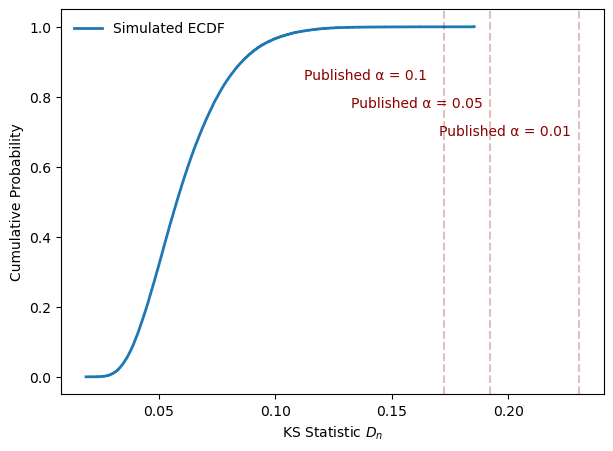

In [6]:
# Kolmogorov-Smirnov ECDF Plot (n = 50)
published_bounds = {  # Lower Bounds
    0.01: 1.63,       # α = 0.01 » pg 281: 0.990
    0.05: 1.36,       # α = 0.05 » pg 280: 0.950
    0.10: 1.22        # α = 0.10 » pg 280: 0.898
}

n = 50
x = x_sorted
y = np.arange(1, x.size + 1) / x.size
y_pos = {0.01: 0.69, 0.05: 0.77, 0.10: 0.85}  # Published Bounds Label Locations

ks_bounds = {a: c / np.sqrt(n) for a, c in published_bounds.items()}

plt.figure(figsize = (7, 5))
plt.step(x, y, where = 'post', label = 'Simulated ECDF', linewidth = 2)

for a, bound in ks_bounds.items():  # Published Lower Bounds
    plt.axvline(bound, color = 'darkred', linestyle = '--', alpha = 0.25)
    plt.text(
        bound - 0.06, y_pos[a], 
        f'Published α = {a}', 
        color = 'darkred'
    )

plt.xlabel(r'KS Statistic $D_n$')
plt.ylabel('Cumulative Probability')
plt.legend(frameon = False)
plt.show()


<div style="margin-top:20px; margin-bottom:20px; font-size:48px; font-weight:bold;">Appendix B</div>


# Anderson-Darling (AD) Statistic
Monte Carlo Simulation to Estimate Distribution & Critical Values


## Initialize Environment

This section of the program imports the necessary Python packages used for the Monte Carlo simulation and analysis.

In [1]:
# Load Packages
import numpy as np
from math import sqrt
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import ceil, floor
from typing import Tuple


## Simulation Functions
Three core functions were developed to carry out the Monte Carlo estimation of the Anderson-Darling (AD) statistic’s null distribution. Together, these functions generate simulated AD values, calculate their empirical quantiles, and estimate confidence intervals for those quantiles.


### 1. Calculate the Anderson-Darling Statistic

`ad_statistic(u_sorted, clip = 1e-12)` calculates the one-sample Anderson–Darling (AD) test statistic under the null hypothesis of a fully specified continuous distribution. The input `u_sorted` is a sorted array of Uniform(0,1) values obtained via the probability integral transform. To ensure numerical stability, the function clips extreme values near 0 and 1 to avoid taking the logarithm of zero. It then applies the Anderson–Darling formula:

$$
A^2 = -n - \frac{1}{n}\sum_{i=1}^{n}(2i - 1)\left[\ln U_{(i)} + \ln(1 - U_{(n+1-i)})\right]
$$

This weights deviations between the empirical and theoretical CDFs more heavily in the tails. The function returns the calculated AD statistic $(A^2)$ as a float.



In [2]:
# Anderson-Darling Statistic
def ad_statistic(u_sorted, clip = 1e-12):
    
    n = u_sorted.size                                         # Sample Size
    U = np.clip(u_sorted, clip, 1.0 - clip)                   # Clip Uniform Values
    
    i = np.arange(1, n + 1, dtype = np.float64)               # Rank 1 - n
    term = (2 * i - 1) * (np.log(U) + np.log(1.0 - U[::-1]))  # Summation Term
    
    A2 = float(-n - np.sum(term) / n)                         # AD Statistic
    
    return A2


### 2. Monte Carlo Simulation of the Anderson–Darling Statistic

`simulate_stat(n, R, rng)` performs a Monte Carlo simulation of the one-sample Anderson–Darling statistic under the null of a fully specified continuous distribution (via the probability integral transform to Uniform(0,1)). For variance reduction, each random sample ($U\in[0,1]^n$) is paired with its antithetic complement (1-U); if ($R$) is odd, one additional independent sample is generated. Each sample is sorted, the statistic is calculated with `ad_statistic`, and the function returns exactly ($R$) simulated ($A^2$) values (the result is sliced to length ($R$) when needed).

<span style="background-color: #fff3b0;"><b>
    Note:</b> This function is replicated across two of the three notebooks with minor changes: Kolmogorov–Smirnov Statistic & Anderson–Darling.
</span>


In [3]:
# Monte Carlo Simulation
def simulate_stat(n, R, rng):

    half = R // 2              # Number of Replications
    U = rng.random((half, n))  # Random Samples
    Uc = 1.0 - U               # Compliments
    
    # Combine Samples into Matrix
    mats = np.vstack([U, Uc])
    if R % 2 == 1:
        mats = np.vstack([mats, rng.random((1, n))])
    mats.sort(axis = 1)
    
    stats = np.apply_along_axis(ad_statistic, 1, mats)  # AD Statistic (minor change)
    
    return stats[:R]


### 3. Confidence Intervals for Quantile Estimates

`quantile_est(x_sorted, q, alpha = 0.05)` calculates an exact confidence interval for a sample quantile using the binomial inversion (Clopper–Pearson) method. The input `x_sorted` is a sorted array of simulated values, `q` is the target quantile (e.g., 0.95), and `alpha` specifies the two-sided significance level (default 0.05 for a 95% confidence interval). The function calculates the total sample size `n`, then determines the lower and upper order-statistic indices (`k_lo`, `k_hi`) by inverting the cumulative binomial distribution at probabilities `alpha / 2` and `1 − alpha / 2`. These indices correspond to the lower and upper bounds of the quantile’s confidence region, and the function returns the associated values from the sorted data array.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This function is replicated across all three notebooks.
</span>


In [4]:
# Quartile Estimates
def quantile_est(x_sorted, q, alpha = 0.05):
    
    n = int(x_sorted.size) # Sample Size
    
    k_lo = int(binom.ppf(alpha / 2, n, q))  # Lower Bound
    k_hi = int(binom.isf(alpha / 2, n, q))  # Upper Bound

    return x_sorted[k_lo], x_sorted[k_hi]


## Main Program

This section defines the simulation parameters, runs the Monte Carlo experiment, and calculates the target quantiles and their 95% confidence intervals for the Anderson-Darling statistic.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This section of the notebook is replicated across two of the three notebooks with minor changes: Kolmogorov–Smirnov Statistic & Anderson–Darling.
</span>


In [5]:
# Simulation Parameters
S = [10, 20, 30, 50, 100, 200]  # Sample Sizes to Simulate
R = 200000                      # Number of Monte Carlo Replications
Q = (0.75, 0.90, 0.95, 0.99)    # Target Quantiles
A = 0.05                        # Significance Level 

rng = np.random.default_rng(7)  # Random Number Generator » Seed = 7


# Monte Carlo Simulation
all_rows = []
for n in S:
    ad_vals = simulate_stat(n, R, rng)
    x_sorted = np.sort(ad_vals)
    
    for p in Q:
        qhat = float(np.quantile(x_sorted, p))
        lo, hi = quantile_est(x_sorted, p, alpha = A)
        all_rows.append((n, p, qhat, lo, hi))
        
        print(f'n = {n:>3}, p = {p:>4}  |  q̂ = {qhat:.4f}  |  95% CI = ({lo:.4f}, {hi:.4f})')


n =  10, p = 0.75  |  q̂ = 1.2482  |  95% CI = (1.2429, 1.2537)
n =  10, p =  0.9  |  q̂ = 1.9479  |  95% CI = (1.9385, 1.9599)
n =  10, p = 0.95  |  q̂ = 2.5204  |  95% CI = (2.5023, 2.5350)
n =  10, p = 0.99  |  q̂ = 3.9316  |  95% CI = (3.8957, 3.9709)
n =  20, p = 0.75  |  q̂ = 1.2439  |  95% CI = (1.2387, 1.2494)
n =  20, p =  0.9  |  q̂ = 1.9338  |  95% CI = (1.9238, 1.9432)
n =  20, p = 0.95  |  q̂ = 2.4957  |  95% CI = (2.4785, 2.5108)
n =  20, p = 0.99  |  q̂ = 3.9050  |  95% CI = (3.8633, 3.9455)
n =  30, p = 0.75  |  q̂ = 1.2475  |  95% CI = (1.2423, 1.2533)
n =  30, p =  0.9  |  q̂ = 1.9512  |  95% CI = (1.9403, 1.9612)
n =  30, p = 0.95  |  q̂ = 2.5261  |  95% CI = (2.5103, 2.5414)
n =  30, p = 0.99  |  q̂ = 3.9248  |  95% CI = (3.8997, 3.9720)
n =  50, p = 0.75  |  q̂ = 1.2478  |  95% CI = (1.2421, 1.2535)
n =  50, p =  0.9  |  q̂ = 1.9384  |  95% CI = (1.9281, 1.9476)
n =  50, p = 0.95  |  q̂ = 2.4948  |  95% CI = (2.4800, 2.5065)
n =  50, p = 0.99  |  q̂ = 3.8172  |  95

### Anderson-Darling ECDF Plot

This section generates an empirical cumulative distribution function (ECDF) plot of the simulated Anderson-Darling (AD) statistic and overlays the published lower critical bounds for comparison.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This section of the notebook is replicated across all three notebooks with minor changes.
</span>


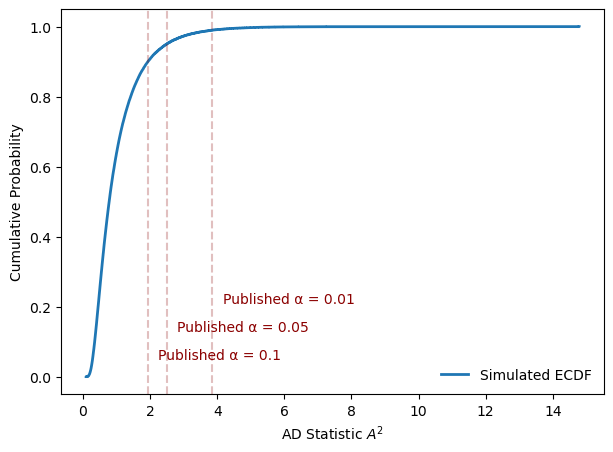

In [6]:
# Anderson-Darling ECDF Plot
published_bounds = {  # Lower Bounds
    0.01: 3.857,      # α = 0.01 » pg 2: 3.8781250216053948842
    0.05: 2.492,      # α = 0.05 » pg 2: 2.4923671600494096176
    0.10: 1.933       # α = 0.10 » pg 2: 1.9329578327415937304
}

x = x_sorted
y = np.arange(1, x.size + 1) / x.size
y_positions = {0.01: 0.21, 0.05: 0.13, 0.10: 0.05}  # Published Bounds Label Locations

plt.figure(figsize = (7, 5))
plt.step(x, y, where = 'post', label = 'Simulated ECDF', linewidth = 2)

for a, bound in published_bounds.items():  # Published Lower Bounds
    plt.axvline(bound, color = 'darkred', linestyle = '--', alpha = 0.25)
    plt.text(
        bound + 0.3, y_positions[a], 
        f'Published α = {a}', 
        color = 'darkred'
    )

plt.xlabel(r'AD Statistic $A^2$')
plt.ylabel('Cumulative Probability')
plt.legend(frameon = False)
plt.show()


<div style="margin-top:20px; margin-bottom:20px; font-size:48px; font-weight:bold;">Appendix C</div>


# Durbin-Watson (DW) Statistic
Monte Carlo Simulation to Estimate Distribution & Critical Values


## Initialize Environment

This section of the program imports the necessary Python packages used for the Monte Carlo simulation and analysis.

In [1]:
# Load Packages
import numpy as np
from math import sqrt
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import ceil, floor
from typing import Tuple


## Simulation Functions
Three core functions were developed to carry out the Monte Carlo estimation of the Durbin–Watson (DW) statistic’s null distribution. Together, these functions generate simulated DW values, calculate their empirical quantiles, and estimate confidence intervals for those quantiles.


### 1. Calculate the Durbin–Watson Statistic

`dw_statistic(eps)` calculates the Durbin–Watson (DW) statistic for an intercept-only regression model under the null hypothesis of no serial correlation. The input `eps` represents a vector of simulated error terms. The function first centers the errors by subtracting their mean, then calculates the ratio of the sum of squared successive differences to the total sum of squared residuals. The resulting value quantifies the degree of autocorrelation, with a DW value near 2 indicating no serial correlation, values below 2 suggesting positive autocorrelation, and values above 2 indicating negative autocorrelation.


In [2]:
# Durbin-Watson Statistic
def dw_statistic(eps):
    
    e = eps - np.mean(eps)        # Centered Residuals
    num = np.sum(np.diff(e)**2)   # Sum of Squared Differences
    denom = np.sum(e**2)          # Total Sum of Squared Residuals
    
    dw_stat = float(num / denom)  # DW Statistic
    
    return dw_stat


### 2. Monte Carlo Simulation of the Durbin–Watson Statistic

`simulate_dw(S, R, rng)` performs a Monte Carlo simulation of the Durbin–Watson statistic. The function generates `R` independent replications, each consisting of `S` normally distributed random errors using a random number generator. For each replication, it calculates the Durbin–Watson statistic using the `dw_statistic()` function and stores the result. The output is a NumPy array of length `R` containing the simulated Durbin–Watson values, which can be used to approximate the statistic’s null distribution and estimate its critical values.


In [3]:
# Monte Carlo Simulation
def simulate_dw(S, R, rng):
    
    dw_stats = np.empty(R, dtype = np.float64)  # Store Simulated DW Statistics
    
    for b in range(R):
        eps = rng.normal(size = S)              # Random Sample of Residuals
        dw_stats[b] = dw_statistic(eps)         # Calculate & Store DW Statistics
        
    return dw_stats


### 3. Confidence Intervals for Quantile Estimates

`quantile_est(x_sorted, q, alpha = 0.05)` calculates an exact confidence interval for a sample quantile using the binomial inversion (Clopper–Pearson) method. The input `x_sorted` is a sorted array of simulated values, `q` is the target quantile (e.g., 0.95), and `alpha` specifies the two-sided significance level (default 0.05 for a 95% confidence interval). The function calculates the total sample size `n`, then determines the lower and upper order-statistic indices (`k_lo`, `k_hi`) by inverting the cumulative binomial distribution at probabilities `alpha / 2` and `1 − alpha / 2`. These indices correspond to the lower and upper bounds of the quantile’s confidence region, and the function returns the associated values from the sorted data array.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This function is replicated across all three notebooks.
</span>


In [4]:
# Quartile Estimates
def quantile_est(x_sorted, q, alpha = 0.05):
    
    n = int(x_sorted.size) # Sample Size
    
    k_lo = int(binom.ppf(alpha / 2, n, q))  # Lower Bound
    k_hi = int(binom.isf(alpha / 2, n, q))  # Upper Bound

    return x_sorted[k_lo], x_sorted[k_hi]


## Main Program

This section defines the simulation parameters, runs the Monte Carlo experiment, and calculates the target quantiles and their 95% confidence intervals for the Durbin–Watson statistic under the null hypothesis of no serial correlation. Because the Durbin–Watson statistic is symmetric about 2, only the upper half of the null distribution (DW > 2) is analyzed here. This upper region corresponds to negative autocorrelation, which is the mirror image of the positive autocorrelation region (DW < 2) tabulated in the original Durbin-Watson tables. As a result, published critical values are reflected as $4 - d_U$ to provide directly comparable reference points for the simulated upper-tail quantiles.


In [5]:
# Simulation Parameters
S = 50                          # Sample Size for Each Simulated Regression
R = 200000                      # Number of Monte Carlo Replications

rng = np.random.default_rng(7)  # Random Number Generator » Seed = 7


# Targets & Confidence Intervals
dw_stats = simulate_dw(S, R, rng)  # Simulated Durbin–Watson Statistic Values
x_sorted = np.sort(dw_stats)       # Simulated Data » Sort Ascending Order


# Calculate Quantile Estimates from Simulated Data
probs = (0.75, 0.90, 0.95, 0.99)
for p in probs:
    qhat = float(np.quantile(x_sorted, p))
    lo, hi = quantile_est(x_sorted, p)
    
    print(f'n = {S:>3}, p = {p:>4}  |  q̂ = {qhat:.3f}  |  95% CI = ({lo:.3f}, {hi:.3f})')


n =  50, p = 0.75  |  q̂ = 2.189  |  95% CI = (2.187, 2.191)
n =  50, p =  0.9  |  q̂ = 2.358  |  95% CI = (2.356, 2.360)
n =  50, p = 0.95  |  q̂ = 2.456  |  95% CI = (2.453, 2.458)
n =  50, p = 0.99  |  q̂ = 2.635  |  95% CI = (2.631, 2.639)


### Durbin-Watson ECDF Plot

This section generates an empirical cumulative distribution function (ECDF) plot of the simulated Durbin–Watson (DW) statistic and overlays the published lower critical bounds for comparison.

<span style="background-color: #fff3b0;"><b>
    Note:</b> This section of the notebook is replicated across all three notebooks with minor changes.
</span>


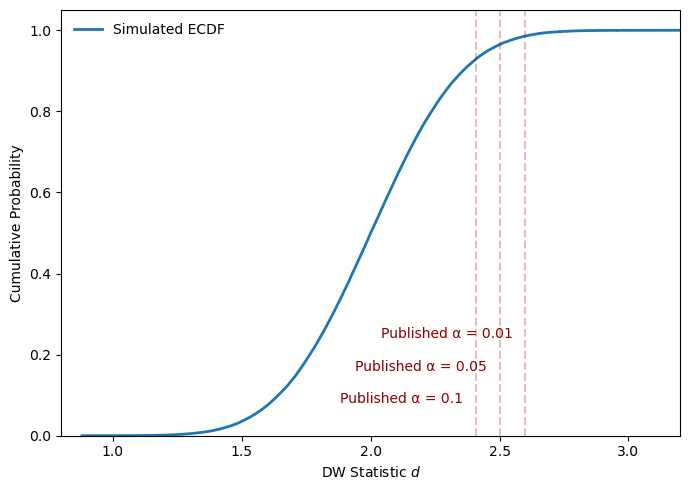

In [6]:
# Durbin–Watson ECDF Plot (n = 50)
published_bounds = {  # Upper Bounds
    0.01: 2.60,       # α = 0.01 » Table 6: 1.32 - 1.40 » 4 - dU = 4 - 1.40 = 2.60
    0.05: 2.50,       # α = 0.05 » Table 5: 1.42 - 1.50 » 4 - dU = 4 - 1.50 = 2.50
    0.10: 2.41        # α = 0.10 » Table 4: 1.50 - 1.59 » 4 - dU = 4 - 1.59 = 2.41
}

x = x_sorted
y = np.arange(1, x.size + 1) / x.size
y_pos = {0.01: 0.25, 0.05: 0.17, 0.10: 0.09}  # Published Bounds Label Locations

plt.figure(figsize = (7, 5))
plt.step(x, y, where = 'post', label = 'Simulated ECDF', linewidth = 2)

for a, bound in published_bounds.items():
    plt.axvline(bound, color = 'darkred', linestyle = '--', alpha = 0.25)
    plt.text(
        bound - 0.05,
        y_pos[a],
        f'Published α = {a}',
        color = 'darkred',
        ha = 'right', va = 'center',
        fontsize = 10
    )

plt.xlabel(r'DW Statistic $d$')
plt.ylabel('Cumulative Probability')
plt.legend(frameon = False)
plt.xlim(0.8, 3.2)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
